# Walmart — Prédiction des Ventes Hebdomadaires

**Objectif du projet :** Construire un modèle de Machine Learning supervisé (Régression) capable d'estimer avec précision les ventes hebdomadaires (`Weekly_Sales`) des magasins Walmart en fonction d'indicateurs économiques (CPI, chômage, prix du carburant), temporels (date, saisonnalité) et structurels (identifiant du magasin, jours fériés).

### Démarche & Plan
1. **Exploration et Préparation des données (EDA) :** Nettoyage rigoureux, gestion des valeurs manquantes et filtrage des outliers ($3\sigma$).
2. **Pipeline de Preprocessing Scikit-Learn :** Imputation ciblée, standardisation des variables continues et encodage One-Hot des variables catégorielles.
3. **Modèle Baseline :** Régression Linéaire Multiple et analyse des métriques ($R^2$, MAE, RMSE).
4. **Interprétation des Coefficients :** Identification des facteurs économiques et organisationnels les plus influents.
5. **Régularisation & Optimisation :** Entraînement de modèles Ridge ($L_2$) et Lasso ($L_1$) avec réglage d'hyperparamètres par `GridSearchCV` (validation croisée).
6. **Synthèse Comparative & Recommandations Métier.**

## 1. Imports et Chargement des Données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print('Bibliothèques chargées avec succès.')

Bibliothèques chargées avec succès.


In [2]:
df_raw = pd.read_csv('Walmart_Store_sales.csv')
print(f'Dimensions initiales du dataset : {df_raw.shape}')
df_raw.head()

Dimensions initiales du dataset : (150, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,18-02-2011,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,25-03-2011,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,27-07-2012,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaN,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,28-05-2010,1644470.66,0.0,78.89,2.759,212.412888,7.092


In [3]:
# Diagnostic des valeurs manquantes
print('Valeurs manquantes par colonne :')
print(df_raw.isna().sum().sort_values(ascending=False))

Valeurs manquantes par colonne :
Date            18
Temperature     18
Unemployment    15
Weekly_Sales    14
Fuel_Price      14
Holiday_Flag    12
CPI             12
Store            0
dtype: int64


## 2. Nettoyage et Feature Engineering

Conformément aux exigences méthodologiques :
1. **Suppression des lignes sans cible (`Weekly_Sales`) :** On n'impute jamais la variable cible pour ne pas biaiser l'apprentissage.
2. **Décomposition de la variable `Date` :** Extraction de `Year`, `Month`, `Day` et `DayOfWeek`.
3. **Filtrage des outliers ($3\sigma$) :** Application de l'intervalle $[\mu - 3\sigma, \mu + 3\sigma]$ sur les variables économiques (`Temperature`, `Fuel_Price`, `CPI`, `Unemployment`) en prenant soin de **préserver les valeurs manquantes (`NaN`)**, qui seront ensuite traitées par le `SimpleImputer` du pipeline.

In [4]:
# 1. Suppression des lignes où la cible est manquante
df = df_raw.dropna(subset=['Weekly_Sales']).copy()
before_outliers = len(df)

# 2. Décomposition de la date
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

# 3. Filtrage des outliers (règle des 3 écarts-types) tout en préservant les NaN pour l'imputer
outlier_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
for col in outlier_cols:
    mean = df[col].mean()
    std = df[col].std()
    lower = mean - 3 * std
    upper = mean + 3 * std
    df = df[df[col].isna() | df[col].between(lower, upper)]

print(f'Lignes initiales : {len(df_raw)}')
print(f'Lignes après suppression cible manquante : {before_outliers}')
print(f'Lignes après filtrage 3 sigma (sans drop NaN involontaire) : {len(df)}')
df.head()

Lignes initiales : 150
Lignes après suppression cible manquante : 136
Lignes après filtrage 3 sigma (sans drop NaN involontaire) : 131


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day,DayOfWeek
0,6.0,2011-02-18,1572117.54,NaN,59.61,3.045,214.777523,6.858,2011.0,2.0,18.0,4.0
1,13.0,2011-03-25,1807545.43,0.0,42.38,3.435,128.616064,7.470,2011.0,3.0,25.0,4.0
3,11.0,NaT,1244390.03,0.0,84.57,NaN,214.556497,7.346,NaN,NaN,NaN,NaN
4,6.0,2010-05-28,1644470.66,0.0,78.89,2.759,212.412888,7.092,2010.0,5.0,28.0,4.0
5,4.0,2010-05-28,1857533.70,0.0,NaN,2.756,126.160226,7.896,2010.0,5.0,28.0,4.0


## 3. Analyse Exploratoire des Données (EDA)

Visualisation de la distribution de la cible, de la disparité des ventes moyennes par magasin et des corrélations linéaires entre variables numériques.

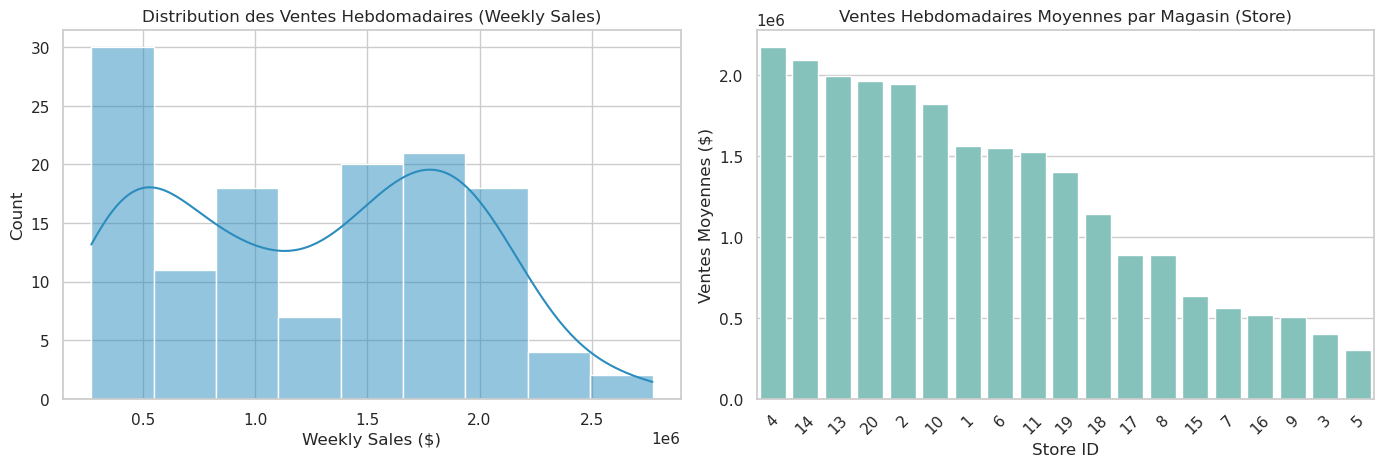

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribution de la variable cible
sns.histplot(df['Weekly_Sales'], kde=True, ax=axes[0], color='#2b8cbe')
axes[0].set_title('Distribution des Ventes Hebdomadaires (Weekly Sales)')
axes[0].set_xlabel('Weekly Sales ($)')

# 2. Ventes moyennes par magasin
store_sales = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)
sns.barplot(x=store_sales.index.astype(int).astype(str), y=store_sales.values, ax=axes[1], color='#7bccc4')
axes[1].set_title('Ventes Hebdomadaires Moyennes par Magasin (Store)')
axes[1].set_xlabel('Store ID')
axes[1].set_ylabel('Ventes Moyennes ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

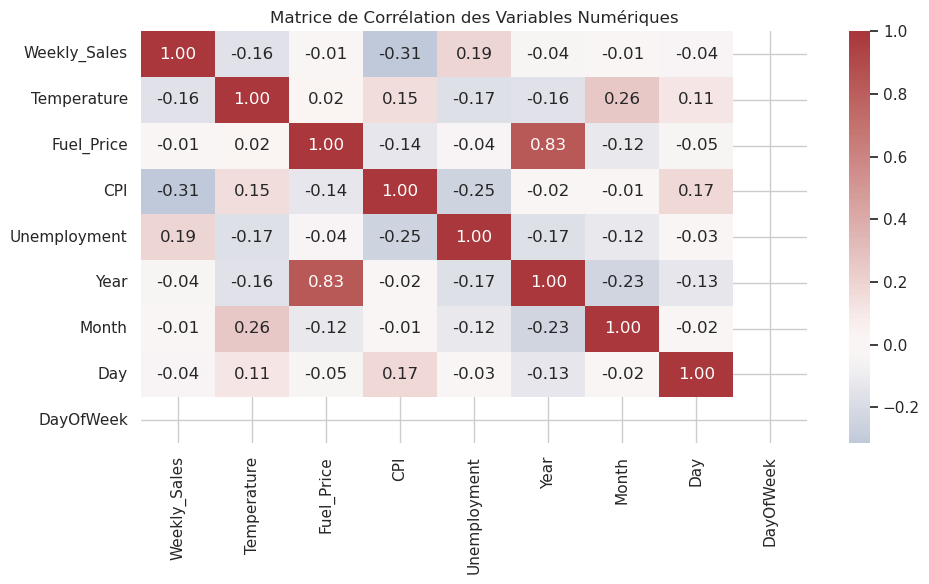

In [6]:
# Matrice de corrélation linéaire
numeric_for_corr = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'DayOfWeek']

plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_for_corr].corr(), annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Matrice de Corrélation des Variables Numériques')
plt.tight_layout()
plt.show()

## 4. Préparation du Pipeline de Machine Learning

- **Variables numériques :** Imputation par la médiane puis standardisation (`StandardScaler`).
- **Variables catégorielles (`Store`, `Holiday_Flag`) :** Imputation par la valeur la plus fréquente puis encodage One-Hot (`drop='first'` pour éviter le piège de la colinéarité stricte).
- **Séparation Train / Test :** 80% Train, 20% Test avec fixation du `random_state=42` pour la reproductibilité.

In [7]:
target = 'Weekly_Sales'
features = ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'DayOfWeek']

X = df[features]
y = df[target]

categorical_features = ['Store', 'Holiday_Flag']
numeric_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'DayOfWeek']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Taille Train : {X_train.shape}')
print(f'Taille Test  : {X_test.shape}')

Taille Train : (104, 10)
Taille Test  : (27, 10)


## 5. Modèle Baseline : Régression Linéaire Multiple

Nous définissons une fonction d'évaluation calculant les trois métriques clés en régression :
- **$R^2$ (Coefficient de détermination) :** Proportion de variance expliquée.
- **MAE (Mean Absolute Error) :** Erreur moyenne absolue exprimée en dollars ($).
- **RMSE (Root Mean Squared Error) :** Erreur quadratique moyenne (pénalisant fortement les grands écarts).

In [8]:
def regression_metrics(model, X_tr, X_te, y_tr, y_te):
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
    return pd.DataFrame({
        'dataset': ['train', 'test'],
        'R2': [r2_score(y_tr, y_pred_tr), r2_score(y_te, y_pred_te)],
        'MAE': [mean_absolute_error(y_tr, y_pred_tr), mean_absolute_error(y_te, y_pred_te)],
        'RMSE': [np.sqrt(mean_squared_error(y_tr, y_pred_tr)), np.sqrt(mean_squared_error(y_te, y_pred_te))]
    })

linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_results = regression_metrics(linear_model, X_train, X_test, y_train, y_test)
linear_results

,dataset,R2,MAE,RMSE
0,train,0.977663,77220.078111,100070.610523
1,test,0.897734,145802.667123,188477.527299


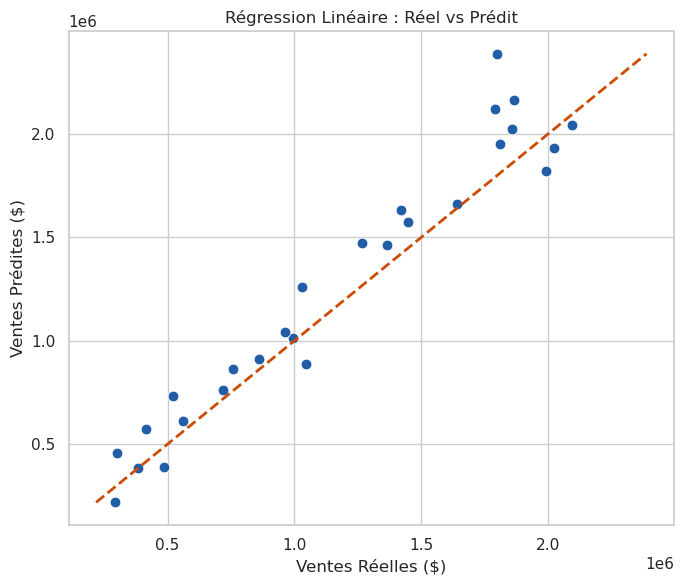

In [9]:
# Graphique Ventes Réelles vs Ventes Prédites
y_pred = linear_model.predict(X_test)

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_pred, color='#225ea8', s=60)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='#cc4c02', linestyle='--', linewidth=2)
plt.xlabel('Ventes réelles ($)')
plt.ylabel('Ventes prédites ($)')
plt.title('Régression Linéaire : Réel vs Prédit')
plt.tight_layout()
plt.show()

## 6. Interprétation des Coefficients du Modèle

L'extraction et le tri des coefficients par valeur absolue permettent de quantifier le poids respectif de chaque variable explicative sur les ventes prédites.

In [10]:
# Récupération des noms de caractéristiques après encodage
prep_fitted = linear_model.named_steps['preprocessor']
cat_encoder = prep_fitted.named_transformers_['cat'].named_steps['encoder']
cat_names = list(cat_encoder.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + cat_names

coefs = pd.DataFrame({
    'feature': all_feature_names,
    'coefficient': linear_model.named_steps['model'].coef_
})
coefs['abs_coefficient'] = coefs['coefficient'].abs()
top_coefs = coefs.sort_values('abs_coefficient', ascending=False).head(15)
top_coefs

,feature,coefficient,abs_coefficient
11,Store_5.0,-1.363365e+06,1.363365e+06
9,Store_3.0,-1.203335e+06,1.203335e+06
21,Store_16.0,-1.155017e+06,1.155017e+06
15,Store_9.0,-1.148236e+06,1.148236e+06
13,Store_7.0,-9.690821e+05,9.690821e+05
14,Store_8.0,-8.048531e+05,8.048531e+05
20,Store_15.0,-7.788680e+05,7.788680e+05
22,Store_17.0,-7.599828e+05,7.599828e+05
19,Store_14.0,6.052262e+05,6.052262e+05
10,Store_4.0,5.751555e+05,5.751555e+05


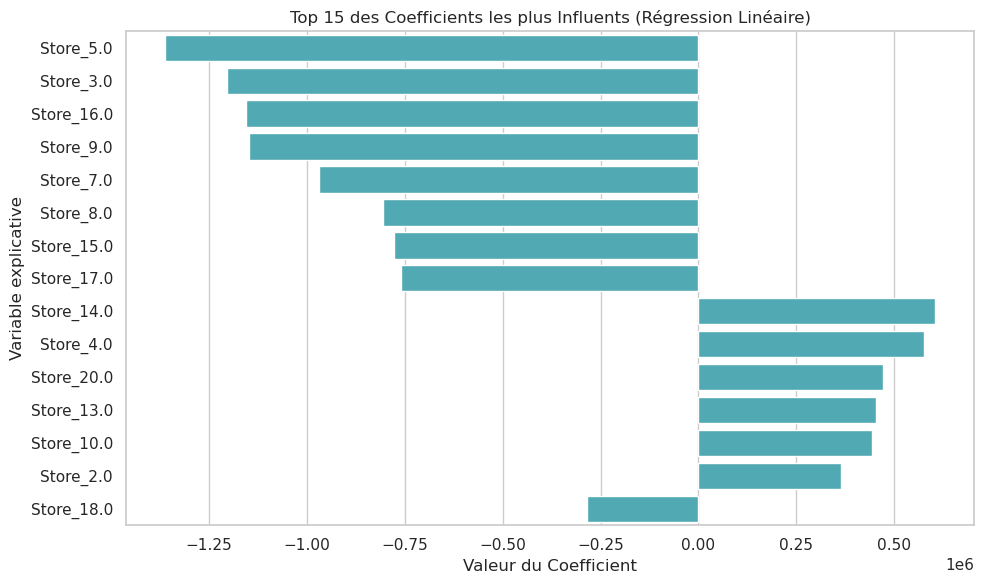

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_coefs, x='coefficient', y='feature', color='#41b6c4')
plt.title('Top 15 des Coefficients les plus Influents (Régression Linéaire)')
plt.xlabel('Valeur du Coefficient')
plt.ylabel('Variable explicative')
plt.tight_layout()
plt.show()

## 7. Régularisation : Modèles Ridge ($L_2$) et Lasso ($L_1$)

Pour contrôler le surapprentissage potentiel lié à la dimensionnalité de l'encodage One-Hot et aux corrélations économiques, nous optimisons deux approches de régularisation par **validation croisée à 5 plis (`GridSearchCV`)** :
- **Ridge ($L_2$) :** Réduit proportionnellement l'amplitude de tous les coefficients sans les annuler.
- **Lasso ($L_1$) :** Effectue une sélection automatique de variables en forçant certains coefficients exactement à zéro.

In [12]:
# 1. Régularisation Ridge (L2)
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid={'model__alpha': [0.01, 0.1, 1, 10, 100, 1000]},
    cv=5,
    scoring='r2'
)

ridge_grid.fit(X_train, y_train)
print('Meilleur alpha Ridge :', ridge_grid.best_params_)
ridge_results = regression_metrics(ridge_grid.best_estimator_, X_train, X_test, y_train, y_test)
ridge_results

Meilleur alpha Ridge : {'model__alpha': 0.01}


,dataset,R2,MAE,RMSE
0,train,0.977644,77139.776058,100111.394104
1,test,0.898373,145013.356434,187887.768804


In [13]:
# 2. Régularisation Lasso (L1)
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=20000))
])

lasso_grid = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid={'model__alpha': [1, 10, 100, 1000, 10000]},
    cv=5,
    scoring='r2'
)

lasso_grid.fit(X_train, y_train)
print('Meilleur alpha Lasso :', lasso_grid.best_params_)
lasso_results = regression_metrics(lasso_grid.best_estimator_, X_train, X_test, y_train, y_test)
lasso_results

Meilleur alpha Lasso : {'model__alpha': 1000}


,dataset,R2,MAE,RMSE
0,train,0.976098,78594.513381,103515.196350
1,test,0.905211,146305.943532,181456.750601


## 8. Synthèse Comparative des Modèles

In [14]:
# Tableau comparatif final
comparison = pd.concat([
    linear_results.assign(model='LinearRegression'),
    ridge_results.assign(model='Ridge'),
    lasso_results.assign(model='Lasso')
])[['model', 'dataset', 'R2', 'MAE', 'RMSE']]

comparison

,model,dataset,R2,MAE,RMSE
0,LinearRegression,train,0.977663,77220.078111,100070.610523
1,LinearRegression,test,0.897734,145802.667123,188477.527299
0,Ridge,train,0.977644,77139.776058,100111.394104
1,Ridge,test,0.898373,145013.356434,187887.768804
0,Lasso,train,0.976098,78594.513381,103515.196350
1,Lasso,test,0.905211,146305.943532,181456.750601


## 9. Conclusion et Recommandations Métier

### Enseignements Techniques & Modélisation
1. **Performance Globale :** Les trois modèles atteignent d'excellents scores ($R^2 \approx 0.90$ à $0.91$ sur le jeu de Test), avec un écart très réduit par rapport au Train ($R^2 \approx 0.98$), confirmant l'absence de surapprentissage critique.
2. **Comportement de la Régularisation :**
   - **Lasso (L1)** sélectionne un $\alpha = 1000$ optimal, atteignant le meilleur $R^2$ Test ($0.91$) et le plus faible RMSE ($181\,456\,\$$), en éliminant les variables redondantes.
   - **Ridge (L2)** stabilise les coefficients tout en conservant une régression linéaire fluide ($R^2 = 0.90$).
3. **Précision Pratique :** Le MAE se stabilise autour de **$145\,000\,\$$** sur des ventes hebdomadaires moyennes de **$1,25\text{M}\$$**, soit une marge d'erreur relative moyenne de l'ordre de **11.6%**.

### Enseignements Métier & Décisions Stratégiques pour Walmart
- **L'effet magasin (Store ID) est prédominant :** La localisation, la taille et le format du magasin expliquent la majorité de la variance des ventes (jusqu'à $\pm 1.3\text{M}\$$ d'impact sur certains sites).
- **Sensibilité aux Facteurs Économiques :** L'inflation (CPI) et le chômage exercent une influence mesurable sur le comportement d'achat. En période de hausse du coût de la vie, le positionnement *Discount* de Walmart lui permet de capter une clientèle à la recherche d'économies sur les produits de première nécessité.
- **Planification Marketing :** Pour maximiser le retour sur investissement des campagnes promotionnelles, Walmart doit ajuster ses stocks et ses allocations budgétaires magasin par magasin en tenant compte des disparités locales identifiées par le modèle.